In [93]:
import numpy as np
import matplotlib.pyplot as plt

In [83]:
class PinholeCamera():
    def __init__(self, K : np.ndarray ,dist_coefs : np.ndarray, world_R_cam : np.ndarray  , world_t_cam : np.ndarray ):
        self.K = K
        self.dist_coefs = dist_coefs
        self.world_R_cam = world_R_cam
        self.world_t_cam = world_t_cam
        self.world_T_cam = np.eye(4)
        self.world_T_cam[:3, :3] = world_R_cam
        self.world_T_cam[:3, 3] = world_t_cam.flatten()

    def project(self, world_pts_3d: np.ndarray) -> np.ndarray:
        n = world_pts_3d.shape[0]
        pts_homo = np.hstack((world_pts_3d, np.ones((n, 1))))
        cam_T_world = np.linalg.inv(self.world_T_cam)
        pts_cam = (cam_T_world @ pts_homo.T).T

        z = pts_cam[:, 2:3]
        z[z<=0] = 1e-6
        pts_2d_norm = pts_cam[:, :2] / z

        x = pts_2d_norm[:, 0]
        y = pts_2d_norm[:, 1]
        r2 = x**2 + y**2
        k1, k2, p1, p2, k3 = self.dist_coefs

        radial = (1 + k1*r2 + k2*r2**2 + k3*r2**3)
        x_dist = x * radial + (2*p1*x*y + p2*(r2 + 2*x**2))
        y_dist = y * radial + (p1*(r2 + 2*y**2) + 2*p2*x*y)

        pts_dist_homo = np.stack((x_dist, y_dist, np.ones_like(x_dist)), axis=1)
        pixels = (self.K @ pts_dist_homo.T).T
        return pixels[:, :2]

    def unproject(self, image_pts_2d: np.ndarray) -> np.ndarray:
        n = image_pts_2d.shape[0]
        pixels_homo = np.hstack((image_pts_2d, np.ones((n, 1))))
        K_inv = np.linalg.inv(self.K)
        pts_dist = (K_inv @ pixels_homo.T).T

        x_d = pts_dist[:, 0]
        y_d = pts_dist[:, 1]
        x, y = x_d, y_d
        k1, k2, p1, p2, k3 = self.dist_coefs

        for _ in range(5):
            r2 = x**2 + y**2
            radial = (1 + k1*r2 + k2*r2**2 + k3*r2**3)
            dx = 2*p1*x*y + p2*(r2 + 2*x**2)
            dy = p1*(r2 + 2*y**2) + 2*p2*x*y
            x = (x_d - dx) / radial
            y = (y_d - dy) / radial

        rays_cam = np.stack((x, y, np.ones_like(x)), axis=1)
        rays_world = (self.world_R_cam @ rays_cam.T).T
        return rays_world / np.linalg.norm(rays_world, axis=1, keepdims=True)

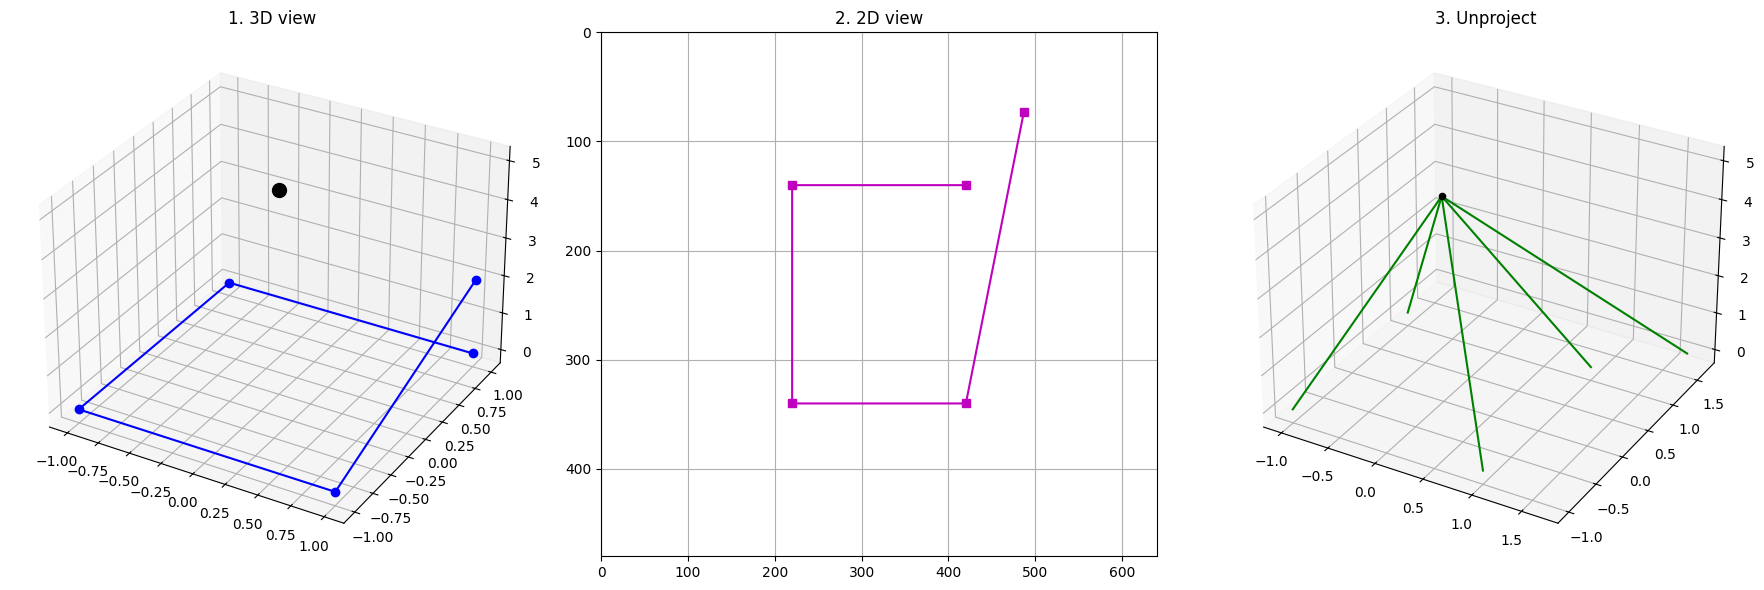

In [95]:
K = np.array([[500, 0, 320], [0, 500, 240], [0, 0, 1]])
dist = np.array([0, 0, 0, 0, 0])

obj_3d = np.array([[1,1,2], [1,-1,0], [-1,-1,0], [-1,1,0], [1,1,0]])

cam_pos = np.array([0, 0, 5])
R = np.array([[1,0,0],
              [0,-1,0],
              [0,0,-1]])

cam = PinholeCamera(K, dist, R, cam_pos)

pixels = cam.project(obj_3d)
rays = cam.unproject(pixels)

fig = plt.figure(figsize=(18, 6))

ax1 = fig.add_subplot(131, projection='3d')
ax1.plot(obj_3d[:,0], obj_3d[:,1], obj_3d[:,2], 'b-o')
ax1.scatter(*cam_pos, color='k', s=100, label='Cam')
ax1.set_title("1. 3D view")

ax2 = fig.add_subplot(132)
ax2.plot(pixels[:,0], pixels[:,1], 'm-s')
ax2.set_xlim(0, 640); ax2.set_ylim(480, 0)
ax2.set_title("2. 2D view")
ax2.grid(True)

ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(*cam_pos, color='k')
for ray in rays:
    t = -cam_pos[2] / ray[2]
    end = cam_pos + ray * t
    ax3.plot([cam_pos[0], end[0]], [cam_pos[1], end[1]], [cam_pos[2], end[2]], 'g-')
ax3.set_title("3. Unproject")

plt.tight_layout()
plt.show()